# 🧲 Muon Momentum Reconstruction with a GRU (V5.1)


Cartesian devations

Huber loss delta = 1


bi-directional


training on 50% of data

relu

dropout .05



In this notebook, we build a **Gated Recurrent Unit (GRU)** neural network that predicts the **momentum** of a muon from its 3D trajectory in the ICARUS LArTPC detector.

---

### What is MCS?
As a muon travels through matter, it gets deflected by tiny random scatterings off atomic nuclei. This is called **Multiple Coulomb Scattering (MCS)**. The higher the muon's energy, the straighter it travels. The lower the energy, the more it wiggles.

```
High KE muon:  →→→→→→→→→→→→→→   (almost straight)
Low  KE muon:  →→↗↘→↗↘→↗↘→↘→   (wiggly)
```

So by measuring how much the track wiggles, we can estimate the KE!


---
## Cell 1 — Import Libraries

We need:
- `pickle` — to load the dataset (stored as a Python object)
- `numpy` — for numerical operations on arrays
- `matplotlib` — for plotting
- `torch` / `torch.nn` — PyTorch deep learning framework

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import h5py
from torch.utils.data import Dataset, DataLoader

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
print(f'Device          : {"GPU" if torch.cuda.is_available() else "CPU (no GPU found)"}')

PyTorch version : 2.4.0.post301
CUDA available  : True
Device          : GPU


---
## Cell 2 — Configuration (Change these to experiment!)

All the important settings are collected here. Try changing these values and re-running the notebook to see how they affect performance!

In [2]:
# ── Data path ───────────────────────────────────────────────────────────────
DATA_PATH = '/exp/icarus/data/users/kyjung/MCS/h5data/muon_pg_samples_ke140-5000MeV_dist50cm_mpvmpr_v4_flat_fix_pca_reco_5cm.h5'

# ── Deviation dataset, which is the input to the GRU model
DEVIATION_PATH = '/exp/icarus/app/users/cruskin/MCS_MLdeviation_full_dataset_noz_reco_5cm_final.npy'


# ── Output paths ────────────────────────────────────────────────────────────
RUN_TAG      = 'Cartdeviation_2d_huber_loss_biD_relu'   # 
SAVE_DIR     = '/exp/icarus/app/users/cruskin/MCS_ML'


MODEL_PATH   = f'{SAVE_DIR}/Default_GRU_{RUN_TAG}_reco.pt'
HISTORY_PATH = f'{SAVE_DIR}/loss_history_{RUN_TAG}_reco.npz'


# ── Model architecture ──────────────────────────────────────────────────────
INPUT_DIM     = 2     # dx, dy
D_MODEL       = 128
NUM_LAYERS    = 4
DROPOUT       = 0.05
BIDIRECTIONAL = True 
LAMBDA_BIAS    = 0.1
PATIENCE   = 20

# ── Training hyperparameters ────────────────────────────────────────────────
LEARNING_RATE   = 3e-4   # step size for gradient descent
EPOCHS          = 100     # number of full passes over the training data
BATCH_SIZE      = 128    # number of samples per gradient update
TRAIN_RATIO     = 0.8    # 80% train, 20% validation
RANDOM_SEED     = 42     # for reproducibility
SUBSET_FRACTION = .5    # 0.1 = use 10% of data (fast test), 1.0 = full dataset

# ── Print summary ────────────────────────────────────────────────────────────
print('Current configuration:')
print(f'  Architecture : GRU  d_model={D_MODEL}, num_layers={NUM_LAYERS}, bidirectional={BIDIRECTIONAL}')
print(f'  Input dim    : {INPUT_DIM}  (dx, dy)')
print(f'  Learning rate: {LEARNING_RATE}')
print(f'  Epochs       : {EPOCHS}')
print(f'  Batch size   : {BATCH_SIZE}')
print(f'  Subset       : {SUBSET_FRACTION*100:.0f}% of data')
print(f'  Deviation set: {DEVIATION_PATH}')


Current configuration:
  Architecture : GRU  d_model=128, num_layers=4, bidirectional=True
  Input dim    : 2  (dx, dy)
  Learning rate: 0.0003
  Epochs       : 100
  Batch size   : 128
  Subset       : 50% of data
  Deviation set: /exp/icarus/app/users/cruskin/MCS_MLdeviation_full_dataset_noz_reco_5cm_final.npy


---
## Cell 3 — Make the Dataset (Run it at frist time only and after that ignore this cell)
3d points to cartesian deviation 

In [3]:
import h5py
import numpy as np
from tqdm import tqdm

#DATA_PATH = ...
#OUT_DIR   = '/exp/icarus/data/users/cruskin/data'
MIN_HITS      = 5       # minimum number of hits needed for the SVD line fit to be meaningful
MUON_MASS     = 105.658   # MeV/c^2

def ke_to_momentum(ke):
    return np.sqrt(ke**2 + 2.0 * ke * MUON_MASS)

with h5py.File(DATA_PATH, 'r') as hf:
    is_contained    = hf['is_contained'][:]
    distance_travel = hf['distance_travel'][:]
    ke              = hf['ke'][:]
    trajectory      = hf['trajectory'][:]

    hit_no = np.array([len(trajectory[i]) // 3 for i in range(len(trajectory))])
    indices = [
        i for i in range(len(distance_travel))
        if is_contained[i] == 0 and hit_no[i] >= MIN_HITS
    ]

print(f'Total tracks  : {len(distance_travel)}')
print(f'"nice" tracks : {len(indices)}')

dev_input    = []   # length differs per track → keep as a list only
momentum_out = []
dist_out     = []
kept_idx     = []

for n in tqdm(indices, desc='Computing deviations', unit='track'):
    hits = trajectory[n].reshape(-1, 3)
    centroid = hits.mean(axis=0)
    _, _, vh = np.linalg.svd(hits - centroid)
    d = vh[0]
    d = d / np.linalg.norm(d)                 # track direction (unit vector)

    # pick a reference vector not parallel to d (if d is close to the z-axis, use the x-axis)
    ref = np.array([0.0, 0.0, 1.0])
    if abs(np.dot(d, ref)) > 0.99:
        ref = np.array([1.0, 0.0, 0.0])

    u = np.cross(d, ref); u /= np.linalg.norm(u)
    v = np.cross(d, u)                         # d, u, v: orthonormal frame

    r      = hits - centroid                   # (L,3)
    t      = r @ d                             # coordinate along the track direction (arc-length)
    r_perp = r - np.outer(t, d)                # perpendicular residual (L,3)

    u_dev = r_perp @ u
    v_dev = r_perp @ v
    z_rel = t - t.min()                         # cumulative distance from the track start point (cylindrical z)

    dev_input.append(np.column_stack((u_dev, v_dev)))   # (L,2)
    momentum_out.append(ke_to_momentum(ke[n]))
    dist_out.append(distance_travel[n])
    kept_idx.append(n)

momentum_out = np.array(momentum_out)
dist_out     = np.array(dist_out)

data_list = [
    {
        'dev'     : dev_input[i],        # (L, 2)  [u_dev, v_dev]
        'momentum': float(momentum_out[i]),
        'dist'    : float(dist_out[i]),
        'idx'     : int(kept_idx[i]),
    }
    for i in range(len(dev_input))
]

np.save(DEVIATION_PATH,
        np.array(data_list, dtype=object))

print('all done, n_tracks =', len(dev_input), ', momentum shape =', momentum_out.shape)

Total tracks  : 94260
"nice" tracks : 82449


Computing deviations: 100%|██████████| 82449/82449 [01:53<00:00, 724.90track/s] 


all done, n_tracks = 82449 , momentum shape = (82449,)


## Cell 4 — Check deviation dataset

In [4]:
# the file actually used by the training notebook (based on Cell 12)
PATH = DEVIATION_PATH

data = np.load(PATH, allow_pickle=True)

N = len(data)
print(f'=== {PATH} ===')
print(f'total tracks : {N}')
print(f'keys         : {list(data[0].keys())}')
print()

# inspect this data directly here
print("Check dataset for NaN or Inf values, and feature ranges:")
all_dev = np.concatenate([d['dev'] for d in data], axis=0)
print('training data NaN:', np.isnan(all_dev).any(), 'Inf:', np.isinf(all_dev).any())
print('abs max:', np.abs(all_dev).max())

moms = np.array([d['momentum'] for d in data])
print('momentum NaN:', np.isnan(moms).any(), 'min:', moms.min(), 'max:', moms.max())

dists = np.array([d['dist'] for d in data])
print('dist NaN:', np.isnan(dists).any(), 'min:', dists.min())

lens = np.array([len(d['dev']) for d in data])
print('track length: min', lens.min(), 'max', lens.max())

print("Check feature ranges and distributions:")
# 1. feature scale — are the mean/std of u_dev and v_dev similar?
#    dev has a different length per track, so it cannot be stacked into an np.array → concatenate everything and check
all_devs = np.concatenate([d['dev'] for d in data], axis=0)   # (total_hits, 2)
for j, name in enumerate(['u_dev', 'v_dev']):
    col = all_devs[:, j]
    print(f'{name}: mean={col.mean():+.2f}, std={col.std():.2f}, range=[{col.min():.1f},{col.max():.1f}]')

# 2. target range — is the momentum in a normal range?
moms = np.array([d['momentum'] for d in data])
print(f'momentum: min={moms.min():.0f}, max={moms.max():.0f}, median={np.median(moms):.0f}')

# 3. NaN/Inf check
print('dev NaN:', np.isnan(all_devs).any(), 'Inf:', np.isinf(all_devs).any())

# 4. (extra) good to also check the per-track length distribution — to gauge the padding ratio
lens = np.array([len(d['dev']) for d in data])
print(f'track length: min={lens.min()}, max={lens.max()}, median={np.median(lens):.0f}, mean={lens.mean():.1f}')

dists = np.array([d['dist'] for d in data])
print('dist: min', dists.min(), 'max', dists.max(), 'mean', dists.mean())
print('dist > 2000:', (dists>2000).sum())

=== /exp/icarus/app/users/cruskin/MCS_MLdeviation_full_dataset_noz_reco_5cm_final.npy ===
total tracks : 82449
keys         : ['dev', 'momentum', 'dist', 'idx']

Check dataset for NaN or Inf values, and feature ranges:
training data NaN: False Inf: False
abs max: 40.312020489786434
momentum NaN: False min: 224.33819354459922 max: 5104.480621577595
dist NaN: False min: 50.00019073486328
track length: min 10 max 338
Check feature ranges and distributions:
u_dev: mean=+0.00, std=1.17, range=[-40.3,39.0]
v_dev: mean=+0.00, std=1.14, range=[-37.0,33.9]
momentum: min=224, max=5104, median=2930
dev NaN: False Inf: False
track length: min=10, max=338, median=51, mean=54.1
dist: min 50.00019073486328 max 1694.7152099609375 mean 265.47960067825085
dist > 2000: 0


---
## Cell 5 — Define the Dataset and Collate Function
Training input (dx,dy,distance) and target is momentum
We can change target as 1/mom or log(mom)

In [5]:
M_MU = 105.658  # MeV, muon rest mass

def ke_to_momentum(ke):
    E = ke + M_MU          # total energy [MeV]
    p = np.sqrt(E**2 - M_MU**2)
    return p


class MuonTrackDataset(Dataset):
    def __init__(self, data, indices):
        self.data    = data
        self.indices = np.array(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        d    = self.data[int(self.indices[idx])]
        deviations = np.array(d['dev'])
        mom  = float(d['momentum'])
        dist = float(d['dist'])

        # ── Build 2-feature input: [dx, dy] ─────────────────────────────
        feats = np.concatenate([
            deviations[:],  # (L, 2) transverse deviations (dx, dy)
        ], axis=1).astype(np.float32)  #
        
        feats = feats[::-1].copy()  #reverse the sequence 
        
        return (
            torch.tensor(feats,      dtype=torch.float32), 
            torch.tensor(dist,       dtype=torch.float32),   # distance_travel (separate)
            torch.tensor(mom, dtype=torch.float32),   # target: momentum p (MeV/c), We can change this part s.t. inverse momentum 1/p or log(p) etc.
        )


#Zero padding
def collate_fn(batch):
    feats_list, dist_list, p_list = zip(*batch)
    max_len = max(f.shape[0] for f in feats_list)
    B       = len(feats_list)
    F       = feats_list[0].shape[1]          # feature 

    padded = torch.zeros(B, max_len, F)                  # ← F features
    mask   = torch.zeros(B, max_len, dtype=torch.bool)

    for i, f in enumerate(feats_list):
        L = f.shape[0]
        padded[i, :L, :] = f
        mask[i, L:]      = True   # True = padding (to be ignored)

    return padded, mask, torch.stack(dist_list), torch.stack(p_list)


#print(f'Total tracks     : {len(all_ke)}')
print(f'mask : {len(data)}')
print()


data = np.load(DEVIATION_PATH, allow_pickle=True)   # directory



# ── Quick test ──────────────────────────────────────────────────────────────
_ds     = MuonTrackDataset(data, [0, 1, 2])
_loader = DataLoader(_ds, batch_size=3, collate_fn=collate_fn)
_x, _m, _d, _y = next(iter(_loader))
print(f'padded shape : {_x.shape}   — (B, max_len, 5)   ← 5 features')
print(f'mask shape   : {_m.shape}   — (B, max_len)  True=padding')
print(f'dist shape   : {_d.shape}   — (B,)')
print(f'inv_p shape  : {_y.shape}   — (B,)')
print()
d0 = data[0]
print(f'First sample dev shape : {np.array(d0["dev"]).shape}')
print(f'  momentum : {d0["momentum"]:.1f} MeV/c')

mask : 82449

padded shape : torch.Size([3, 101, 2])   — (B, max_len, 5)   ← 5 features
mask shape   : torch.Size([3, 101])   — (B, max_len)  True=padding
dist shape   : torch.Size([3])   — (B,)
inv_p shape  : torch.Size([3])   — (B,)

First sample dev shape : (46, 2)
  momentum : 5008.9 MeV/c


---
## Cell 6 — Train/Validation Split + Build DataLoaders

### Why split the data?
We need to know if our model **generalizes** to new data it has never seen. So we:
- Train on 80% of the data
- Evaluate on the remaining 20% (validation set)

.

In [6]:
np.random.seed(RANDOM_SEED)
idx = np.random.permutation(len(data))

# ── Subset (for fast testing) ───────────────────────────────────────────────
n_subset = int(len(idx) * SUBSET_FRACTION)
idx      = idx[:n_subset]

# ── Split AFTER applying subset ─────────────────────────────────────────────
n_train   = int(len(idx) * TRAIN_RATIO)
train_idx = idx[:n_train]
val_idx   = idx[n_train:]

print(f'Training samples  : {len(train_idx)}')
print(f'Validation samples: {len(val_idx)}')
print()

train_loader = DataLoader(
    MuonTrackDataset(data, train_idx),
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    collate_fn  = collate_fn,
)
val_loader = DataLoader(
    MuonTrackDataset(data, val_idx),
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    collate_fn  = collate_fn,
)

print(f'Train DataLoader : {len(train_loader)} batches × {BATCH_SIZE} samples/batch')
print(f'Val   DataLoader : {len(val_loader)} batches × {BATCH_SIZE} samples/batch')
print()

# ── Peek at one batch ──────────────────────────────────────────────────────
X_batch, M_batch, D_batch, y_batch = next(iter(train_loader))
print(f'One batch shapes:')
print(f'  X_batch (feats) : {X_batch.shape}   — (batch_size, max_seq_len, 5)')
print(f'  M_batch (mask)  : {M_batch.shape}   — (batch_size, max_seq_len)')
print(f'  D_batch (dist)  : {D_batch.shape}   — (batch_size,)')
print(f'  y_batch (p)   : {y_batch.shape}   — (batch_size,)')
print(f'  y_batch values: {y_batch[:5]}')   # 

Training samples  : 32979
Validation samples: 8245

Train DataLoader : 258 batches × 128 samples/batch
Val   DataLoader : 65 batches × 128 samples/batch

One batch shapes:
  X_batch (feats) : torch.Size([128, 191, 2])   — (batch_size, max_seq_len, 5)
  M_batch (mask)  : torch.Size([128, 191])   — (batch_size, max_seq_len)
  D_batch (dist)  : torch.Size([128])   — (batch_size,)
  y_batch (p)   : torch.Size([128])   — (batch_size,)
  y_batch values: tensor([3880.0505, 4686.6382, 4009.2910, 1024.2894, 3944.3801])


## Cell 7 — Build the GRU Model
Our GRU looks like this (defaults: `D_MODEL=128`, `NUM_LAYERS=4`):


Input: (B, L, 2)  — B tracks, L segments (padded), 2 features each (dx, dy)
Linear(2 → 128)              — project to hidden dim
+ dist_proj(distance_travel)  — add track length at step 0
  GRU(128, num_layers=4)        — read the sequence
  LayerNorm
  MLP head → 1 output
Output: (B,)  — predicted momentum p [MeV/c]


In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class MuonMomentumGRU(nn.Module):
    def __init__(self,
                 input_dim     = 2,      # (dx,dy)
                 d_model       = 128,
                 num_layers    = 4,
                 dropout       = 0.1,
                 bidirectional = True):
        super().__init__()

        self.bidirectional = bidirectional
        self.d_out = d_model * 2 if bidirectional else d_model

        self.input_proj = nn.Linear(input_dim, d_model)

        # Embed distance_travel (scalar) → d_model 
        self.dist_proj = nn.Sequential(
            nn.Linear(1, d_model),
            nn.ReLU(),
            nn.Linear(d_model, d_model),
        )

        # GRU layer
        self.gru = nn.GRU(
            input_size    = d_model,
            hidden_size   = d_model,
            num_layers    = num_layers,
            batch_first   = True,
            dropout       = dropout if num_layers > 1 else 0,
            bidirectional = bidirectional,
        )

        self.norm_out = nn.LayerNorm(self.d_out)

        # MLP head to predict p
        self.head = nn.Sequential(
            nn.Linear(self.d_out * 2, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Linear(d_model // 2, 1),
        )


    def forward(self, x, padding_mask, dist):
        # x            : (B, L, F)  — padded F-feature sequences (F=2: dx, dy)
        # padding_mask : (B, L)     — True where padding
        # dist         : (B,)       — distance_travel for each track
        B, L, F = x.shape
        
        # Step 1: Project F features → d_model
        x = self.input_proj(x)
    
        # Step 2: Embed distance_travel and inject into first segment, # We can remmove this part if we don't want to use distance_travel as an input feature
        dist_emb   = self.dist_proj(dist.unsqueeze(-1))   # (B, d_model)
        x[:, 0, :] = x[:, 0, :] + dist_emb               # add to first step only
    
        # Step 3: Pack → GRU skips padding positions
        lengths = (1 - padding_mask.float()).sum(dim=1).long().cpu()
        lengths = torch.clamp(lengths, min=1)
        packed  = nn.utils.rnn.pack_padded_sequence(
            x, lengths, batch_first=True, enforce_sorted=False
        )
    
        # Step 4: Run GRU
        out_packed, _ = self.gru(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(
            out_packed, batch_first=True, total_length=L
        )   # (B, L, d_out)
    
        out = self.norm_out(out)
    
        first_out  = out[:, 0, :]
        pad_expand = padding_mask.unsqueeze(-1).float()
        out_masked = out * (1 - pad_expand)
        n_valid    = (1 - padding_mask.float()).sum(dim=1, keepdim=True)
        mean_out   = out_masked.sum(dim=1) / (n_valid + 1e-8)
    
        combined = torch.cat([first_out, mean_out], dim=-1)
        return self.head(combined).squeeze(-1)   # (B,)


model = MuonMomentumGRU(
    input_dim     = INPUT_DIM,
    d_model       = D_MODEL,
    num_layers    = NUM_LAYERS,
    dropout       = DROPOUT,
    bidirectional = BIDIRECTIONAL,
).to(device)

n_params = sum(p.numel() for p in model.parameters()
               )
print('Model architecture:')
print(model)
print()
print(f'Total trainable parameters: {n_params:,}')
print()
print(f'This GRU has {n_params:,}')

Model architecture:
MuonMomentumGRU(
  (input_proj): Linear(in_features=2, out_features=128, bias=True)
  (dist_proj): Sequential(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (gru): GRU(128, 128, num_layers=4, batch_first=True, dropout=0.05, bidirectional=True)
  (norm_out): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (head): Sequential(
    (0): Linear(in_features=512, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.05, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total trainable parameters: 1,179,137

This GRU has 1,179,137


---
## Cell 8 — Define Optimizer, Loss Function, and Scheduler

### Loss function
We use fractional MSE instead of plain MSE:

### Optimizer (AdamW)
Same idea as Adam but with **weight decay** — a regularization that prevents weights from growing too large.

### Scheduler (CosineAnnealingLR)
The learning rate starts at `LEARNING_RATE` and smoothly decreases to near zero by the end of training.

In [8]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# We can change loss function here.
# huber loss from https://arjun-sarkar786.medium.com/implementation-of-all-loss-functions-deep-learning-in-numpy-tensorflow-and-pytorch-e20e72626ebd
def loss_fn(pred, target):
    loss_h = nn.HuberLoss()
    return loss_h(pred, target)
    


scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max   = EPOCHS,
    eta_min = LEARNING_RATE * 0.01,
)

print('Training setup:')
print(f'  Optimizer : AdamW  (initial lr = {LEARNING_RATE}, weight_decay=1e-4)')
print(f'  Loss      : Huber ')
print(f'  Scheduler : CosineAnnealingLR  (lr decays to {LEARNING_RATE * 0.01:.2e} over {EPOCHS} epochs)')

Training setup:
  Optimizer : AdamW  (initial lr = 0.0003, weight_decay=1e-4)
  Loss      : Huber 
  Scheduler : CosineAnnealingLR  (lr decays to 3.00e-06 over 100 epochs)


---
## Cell 9 — Training Loop

This is the core training loop. For each epoch:

1. **Forward pass**: feed input X (+ mask + distance) through the model, get predictions
2. **Compute loss**: compare predictions to ground truth
3. **Backward pass**: compute gradients
4. **Clip gradients**: prevent exploding gradients
5. **Update weights**: take a step in the direction that reduces loss

After each epoch, we evaluate on the validation set to track generalization.

In [9]:
import time
import numpy as np

# ── how long to wait for improvement ─────────────────────────────────────────

# ── Tracking ────────────────────────────────────────────────────────────────
train_loss_history = []
val_loss_history   = []

best_val_loss = float('inf')
best_epoch    = 0
best_weights  = None
best_preds    = None
best_trues    = None
no_improve    = 0

print(f'{"Epoch":>6} | {"TrainL":>10} | {"ValL":>10} | {"MAE":>8} | {"σ68":>6} | {"bias":>7} | Note')
print('-' * 70)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # ── TRAINING ────────────────────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0
    for X_batch, M_batch, D_batch, y_batch in train_loader:
        X_batch, M_batch = X_batch.to(device), M_batch.to(device)
        D_batch, y_batch = D_batch.to(device), y_batch.to(device)

        p_pred = model(X_batch, M_batch, D_batch).squeeze(-1)
        loss   = loss_fn(p_pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()
    avg_train_loss = epoch_loss / len(train_loader)
    scheduler.step()

    # ── VALIDATION  ──────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    preds_log, trues_log = [], []
    with torch.no_grad():
        for X_batch, M_batch, D_batch, y_batch in val_loader:
            X_batch, M_batch = X_batch.to(device), M_batch.to(device)
            D_batch, y_batch = D_batch.to(device), y_batch.to(device)
            pred = model(X_batch, M_batch, D_batch).squeeze(-1)
            val_loss += loss_fn(pred, y_batch).item()
            preds_log.append(pred.cpu())
            trues_log.append(y_batch.cpu())
    avg_val_loss = val_loss / len(val_loader)

    preds   = torch.cat(preds_log).numpy()   
    trues   = torch.cat(trues_log).numpy()
    #depends on how you define target label, you might need to convert 1/p to p if you define target as 1/p
    resid   = (preds - trues) / trues
    mae     = np.mean(np.abs(preds - trues))
    sigma68 = np.percentile(np.abs(resid), 68)
    bias    = np.mean(resid)

    train_loss_history.append(avg_train_loss)
    val_loss_history.append(avg_val_loss)

    # ── Best + early stopping ────────────────────────────
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch    = epoch
        no_improve    = 0
        best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
        best_preds, best_trues = preds.copy(), trues.copy()
        torch.save({
            'epoch'       : epoch,
            'model_state' : model.state_dict(),
            'optimizer'   : optimizer.state_dict(),
            'val_loss'    : best_val_loss,
            'val_mae'     : mae,
            'val_sigma68' : sigma68,
            'val_bias'    : bias,
            'config'      : {
                'input_dim'    : INPUT_DIM,
                'd_model'      : D_MODEL,
                'num_layers'   : NUM_LAYERS,
                'dropout'      : DROPOUT,
                'bidirectional': BIDIRECTIONAL,
            },
    'train_loss_history': train_loss_history,   # Save loss histogry in mdoel too for every epoch.
    'val_loss_history'  : val_loss_history,     # 
        }, MODEL_PATH)
        note = '← best (saved)'
    else:
        no_improve += 1
        note = f'no improve {no_improve}/{PATIENCE}'

    elapsed = time.time() - t0
    print(f'{epoch:6d} | {avg_train_loss:10.4f} | {avg_val_loss:10.4f} | '
          f'{mae:8.1f} | {sigma68:6.3f} | {bias:7.3f} | {note}  ({elapsed:.1f}s)')

    if no_improve >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}')
        break


#Save loss history
np.savez(HISTORY_PATH,
         train=np.array(train_loss_history),
         val=np.array(val_loss_history),
         best_epoch=best_epoch)
# ── Restore best weights ────────────────────────────────────────────────────
model.load_state_dict(best_weights)
print()
print('Training complete!')
print(f'  Best epoch    : {best_epoch}')
print(f'  Best Val Loss : {best_val_loss:.6f}')
print(f'  Best MAE      : {np.mean(np.abs(best_preds - best_trues)):.1f} MeV/c')
print(f'  Saved → {MODEL_PATH}')

 Epoch |     TrainL |       ValL |      MAE |    σ68 |    bias | Note
----------------------------------------------------------------------
     1 |  2688.1402 |  2150.6780 |   2150.0 |  0.794 |  -0.639 | ← best (saved)  (73.2s)
     2 |  1343.8486 |   718.4512 |    718.5 |  0.302 |  -0.006 | ← best (saved)  (69.2s)
     3 |   640.5479 |   610.7705 |    611.5 |  0.280 |   0.142 | ← best (saved)  (70.6s)
     4 |   592.4357 |   593.8673 |    593.6 |  0.255 |  -0.005 | ← best (saved)  (70.4s)
     5 |   568.0024 |   543.3918 |    544.2 |  0.233 |   0.055 | ← best (saved)  (70.5s)
     6 |   546.1976 |   531.4110 |    532.3 |  0.238 |   0.083 | ← best (saved)  (68.5s)
     7 |   530.0793 |   514.1850 |    514.7 |  0.224 |   0.032 | ← best (saved)  (70.7s)
     8 |   512.2812 |   501.6194 |    501.6 |  0.222 |   0.051 | ← best (saved)  (67.4s)
     9 |   502.1689 |   498.4677 |    498.8 |  0.217 |   0.055 | ← best (saved)  (70.6s)
    10 |   498.5711 |   495.9176 |    496.1 |  0.217 |   0

---
## Cell 10 — Visualize Results

In [10]:
#After you restart this notebook, you can load the model without retraining:
#1. import all the libaray and model path
#2. define the model class, and then load data and the model using the upper code block upto making model + validation data.
checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
cfg = checkpoint['config']
model.load_state_dict(checkpoint['model_state']) #call best trained model weights
model.eval()
print(f"Loaded: epoch={checkpoint['epoch']} | "
      f"MAE={checkpoint['val_mae']:.1f} | σ68={checkpoint['val_sigma68']:.3f} | "
      f"bias={checkpoint['val_bias']:.3f}")

# ── Evaluate → rebuild preds/trues ───────────────────────────────────────────
preds, trues, dists = [], [], []
with torch.no_grad():
    for X_batch, M_batch, D_batch, y_batch in val_loader:
        X_batch, M_batch = X_batch.to(device), M_batch.to(device)
        D_batch = D_batch.to(device)
        pred = model(X_batch, M_batch, D_batch).squeeze(-1)
        preds.append(pred.cpu())
        trues.append(y_batch.cpu())
        dists.append(D_batch.cpu())      # distance_travel

preds = torch.cat(preds).numpy()  #if log then convert to exp
trues = torch.cat(trues).numpy()
dists = torch.cat(dists).numpy()       # track length (raw units, e.g. cm)
print(f'preds {preds.shape}  range {preds.min():.0f}~{preds.max():.0f}')
print(f'trues {trues.shape}  range {trues.min():.0f}~{trues.max():.0f}')


Loaded: epoch=26 | MAE=469.6 | σ68=0.200 | bias=0.027
preds (8245,)  range 283~4956
trues (8245,)  range 250~5104


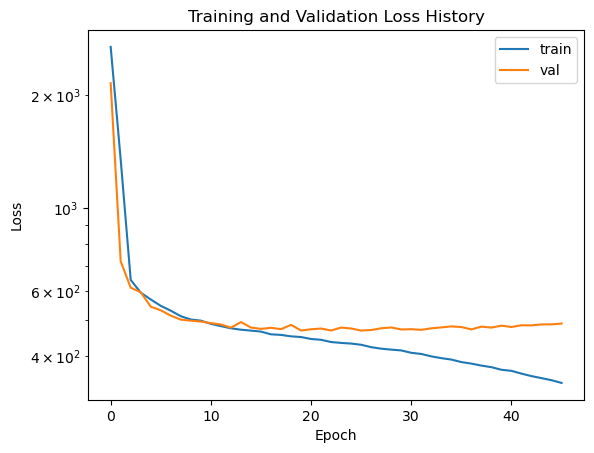

In [11]:
h = np.load(HISTORY_PATH)
plt.plot(h['train'], label='train'); plt.plot(h['val'], label='val')
plt.legend(); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Training and Validation Loss History')
plt.yscale('log')

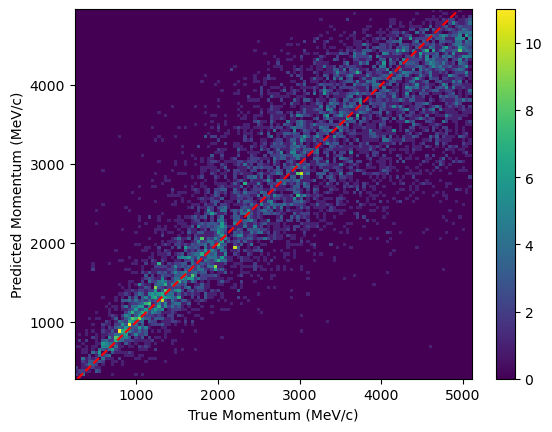

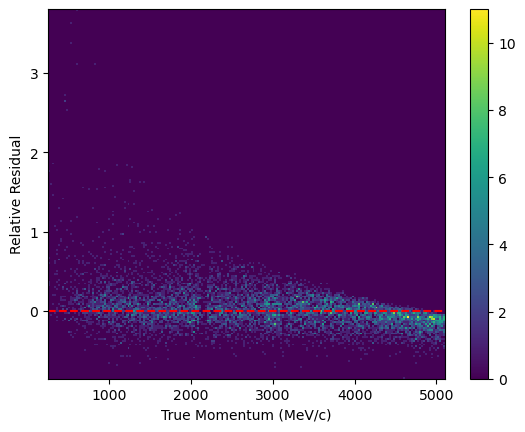

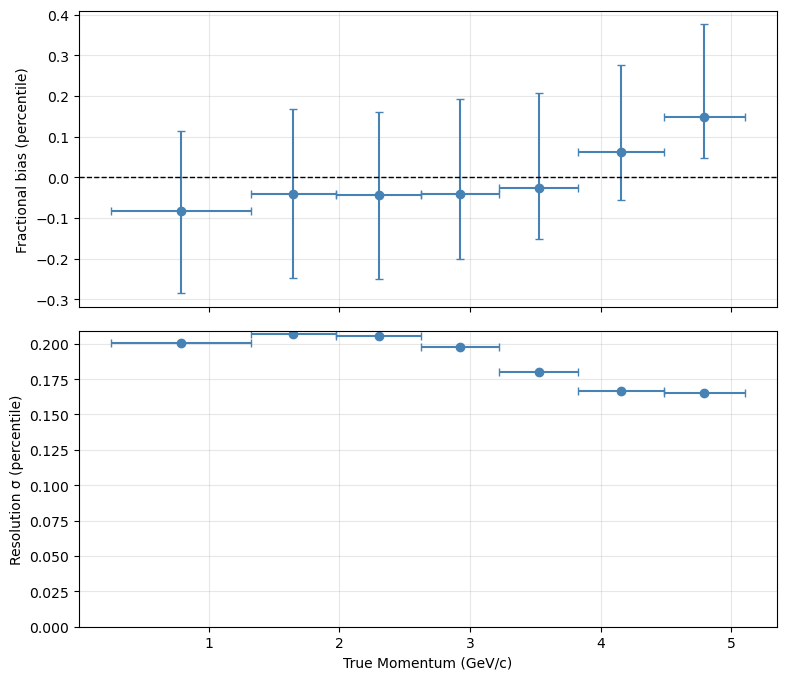

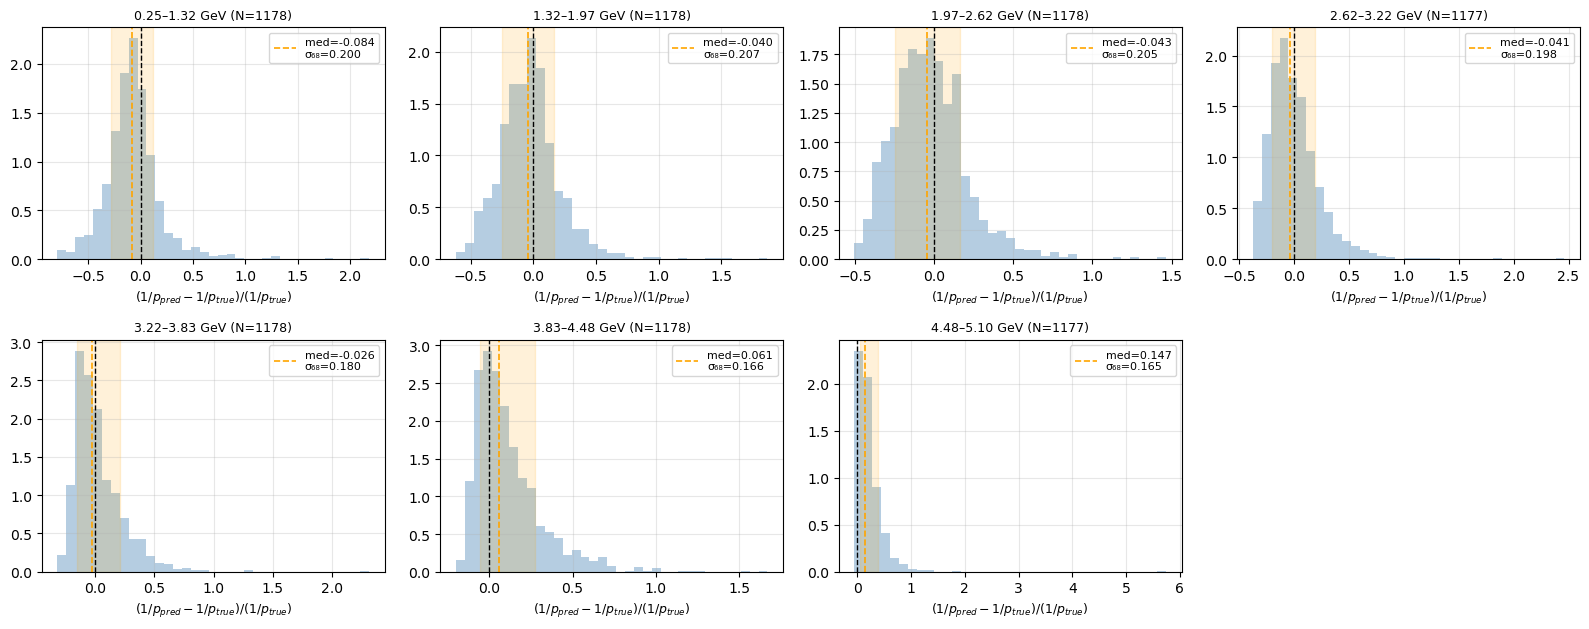

In [12]:
from scipy.stats import norm

METHOD = 'percentile'      # Select 'gaussian' or 'percentile'

# ── Pred vs True ─────────────────────────────────────────────────────────────
plt.axline((0, 0), slope=1, color='red', linestyle='--')
plt.hist2d(trues, preds, bins=120)
plt.colorbar()
plt.xlabel('True Momentum (MeV/c)')
plt.ylabel('Predicted Momentum (MeV/c)')
plt.show()

# ── Relative residual vs True ────────────────────────────────────────────────
rel_resid = preds / trues - 1.0          # (p_pred - p_true)/(p_true)
plt.hist2d(trues, rel_resid, bins=200)
plt.colorbar()
plt.axline((0, 0), slope=0, color='red', linestyle='--')
plt.xlabel('True Momentum (MeV/c)')
plt.ylabel('Relative Residual')
#plt.ylim(-1,1)
plt.show()

# ── Bias & resolution vs True ────────────────────────────────────────────────
resid   = trues / preds - 1.0            #  (1/p_pred - 1/p_true)/(1/p_true)
ok      = np.isfinite(resid) & (trues > 0) & (preds > 0)
trues_f = trues[ok]
resid_f = resid[ok]

N_BINS  = 7
edges   = np.percentile(trues_f, np.linspace(0, 100, N_BINS + 1))
centers = (edges[:-1] + edges[1:]) / 2 / 1000
xwidth  = (edges[1:] - edges[:-1]) / 2 / 1000

mu_vals, sig_vals, lo_err, hi_err = [], [], [], []
bin_r = []
for a, b in zip(edges[:-1], edges[1:]):
    r = resid_f[(trues_f >= a) & (trues_f < b)]
    bin_r.append((r, a, b))
    if len(r) < 10:
        for L in (mu_vals, sig_vals, lo_err, hi_err): L.append(np.nan)
        continue
    if METHOD == 'gaussian':
        mu, sg = norm.fit(r)
        mu_vals.append(mu); sig_vals.append(sg)
        lo_err.append(sg);  hi_err.append(sg)        # symmetric
    else:  # percentile
        p16, p50, p84 = np.percentile(r, [16, 50, 84])
        mu_vals.append(p50); sig_vals.append((p84 - p16) / 2)
        lo_err.append(p50 - p16); hi_err.append(p84 - p50)  # asymmetric

mu_vals = np.array(mu_vals); sig_vals = np.array(sig_vals)
yerr    = np.array([lo_err, hi_err])

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)
fig.subplots_adjust(hspace=0.08)

axes[0].errorbar(centers, mu_vals, xerr=xwidth, yerr=yerr, fmt='o',
                 color='steelblue', capsize=3)
axes[0].axhline(0, color='black', ls='--', lw=1)
axes[0].set_ylabel(f'Fractional bias ({METHOD})')
axes[0].grid(True, alpha=0.3)

axes[1].errorbar(centers, sig_vals, xerr=xwidth, fmt='o',
                 color='steelblue', capsize=3)
axes[1].set_ylabel(f'Resolution σ ({METHOD})')
axes[1].set_xlabel('True Momentum (GeV/c)')
axes[1].set_ylim(bottom=0)
axes[1].grid(True, alpha=0.3)
plt.show()

# ── Per-bin residual ─────────────────────────────────────────────────────────
ncols = 4
nrows = int(np.ceil(N_BINS / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.2*nrows))
axes = axes.flatten()
for k, (r, a, b) in enumerate(bin_r):
    ax = axes[k]
    if len(r) < 10:
        ax.set_visible(False); continue
    ax.hist(r, bins=35, density=True, color='steelblue', alpha=0.4)
    if METHOD == 'gaussian':
        mu, sg = norm.fit(r)
        xf = np.linspace(r.min(), r.max(), 200)
        ax.plot(xf, norm.pdf(xf, mu, sg), 'r-', lw=1.5, label=f'μ={mu:.3f}\nσ={sg:.3f}')
        ax.axvline(mu, color='orange', ls='--', lw=1)
    else:  # percentile
        p16, p50, p84 = np.percentile(r, [16, 50, 84])
        ax.axvline(p50, color='orange', ls='--', lw=1.2, label=f'med={p50:.3f}\nσ₆₈={(p84-p16)/2:.3f}')
        ax.axvspan(p16, p84, color='orange', alpha=0.15)
    ax.axvline(0, color='black', ls='--', lw=1)
    ax.set_title(f'{a/1000:.2f}–{b/1000:.2f} GeV (N={len(r)})', fontsize=9)
    ax.set_xlabel(r'$(1/p_{pred} - 1/p_{true}) / (1/p_{true})$', fontsize=9)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
for k in range(len(bin_r), len(axes)):
    axes[k].set_visible(False)
plt.tight_layout()
plt.show()

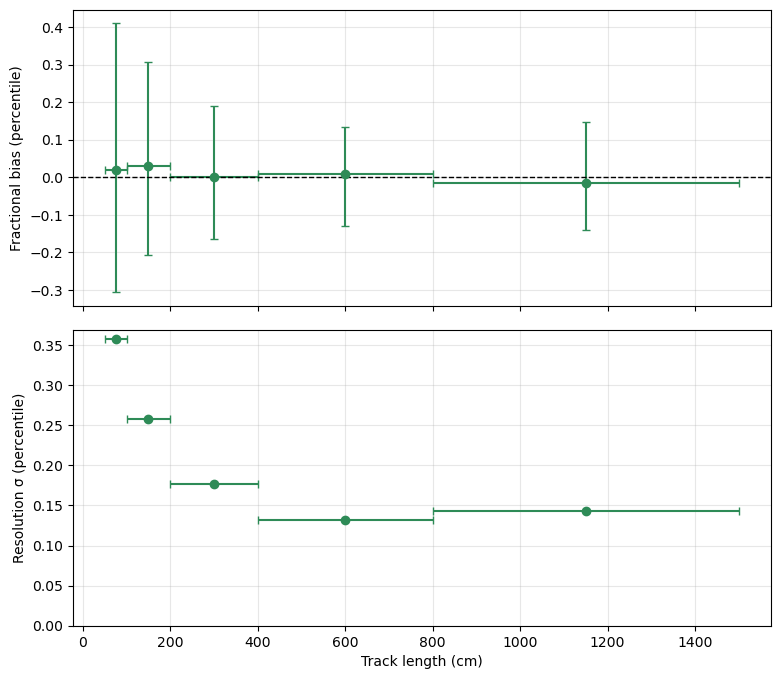

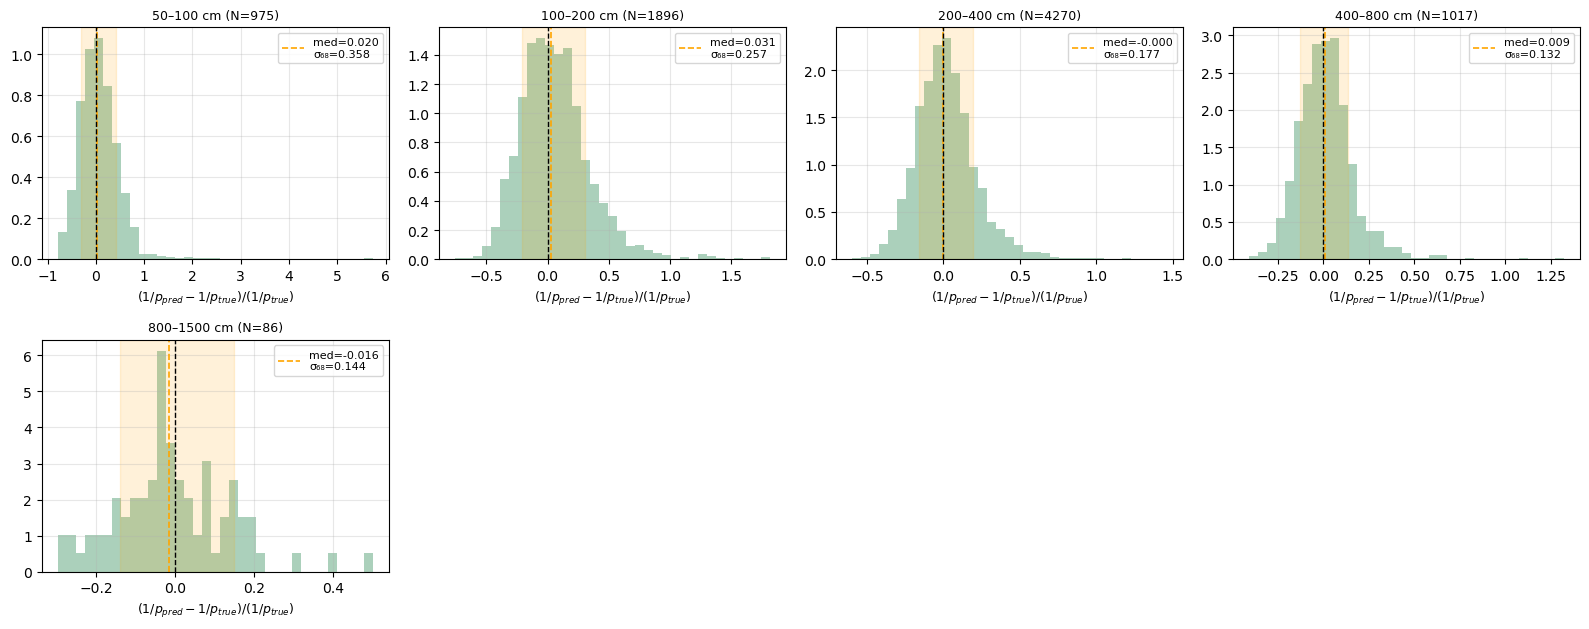

In [13]:
# Bias & resolution vs TRACK LENGTH (distance_travel, cm)
LEN_BINS = [50,100, 200, 400, 800, 1500, 3000]   # customized bin edges in cm (edit here)

# ── Residual (same definition as the momentum plot) ─────────────────────────
resid   = trues / preds - 1.0            # (1/p_pred - 1/p_true)/(1/p_true)
ok      = np.isfinite(resid) & (trues > 0) & (preds > 0) & np.isfinite(dists)
dist_f  = dists[ok]
resid_f = resid[ok]

edges   = np.asarray(LEN_BINS, dtype=float)
centers = (edges[:-1] + edges[1:]) / 2
xwidth  = (edges[1:] - edges[:-1]) / 2

mu_vals, sig_vals, lo_err, hi_err = [], [], [], []
bin_r = []
for a, b in zip(edges[:-1], edges[1:]):
    r = resid_f[(dist_f >= a) & (dist_f < b)]
    bin_r.append((r, a, b))
    if len(r) < 10:
        for L in (mu_vals, sig_vals, lo_err, hi_err): L.append(np.nan)
        continue
    if METHOD == 'gaussian':
        mu, sg = norm.fit(r)
        mu_vals.append(mu); sig_vals.append(sg)
        lo_err.append(sg);  hi_err.append(sg)              
    else:  # percentile
        p16, p50, p84 = np.percentile(r, [16, 50, 84])
        mu_vals.append(p50); sig_vals.append((p84 - p16) / 2)
        lo_err.append(p50 - p16); hi_err.append(p84 - p50) 

mu_vals = np.array(mu_vals); sig_vals = np.array(sig_vals)
yerr    = np.array([lo_err, hi_err])

# ── Bias & resolution vs track length ───────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)
fig.subplots_adjust(hspace=0.08)

axes[0].errorbar(centers, mu_vals, xerr=xwidth, yerr=yerr, fmt='o',
                 color='seagreen', capsize=3)
axes[0].axhline(0, color='black', ls='--', lw=1)
axes[0].set_ylabel(f'Fractional bias ({METHOD})')
axes[0].grid(True, alpha=0.3)

axes[1].errorbar(centers, sig_vals, xerr=xwidth, fmt='o',
                 color='seagreen', capsize=3)
axes[1].set_ylabel(f'Resolution σ ({METHOD})')
axes[1].set_xlabel('Track length (cm)')
axes[1].set_ylim(bottom=0)
axes[1].grid(True, alpha=0.3)
plt.show()

# ── Per-bin residual ────────────────────────────────────────────────────────
N_len = len(bin_r)
ncols = 4
nrows = int(np.ceil(N_len / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.2*nrows))
axes = np.atleast_1d(axes).flatten()
for k, (r, a, b) in enumerate(bin_r):
    ax = axes[k]
    if len(r) < 10:
        ax.set_visible(False); continue
    ax.hist(r, bins=35, density=True, color='seagreen', alpha=0.4)
    if METHOD == 'gaussian':
        mu, sg = norm.fit(r)
        xf = np.linspace(r.min(), r.max(), 200)
        ax.plot(xf, norm.pdf(xf, mu, sg), 'r-', lw=1.5, label=f'μ={mu:.3f}\nσ={sg:.3f}')
        ax.axvline(mu, color='orange', ls='--', lw=1)
    else:  # percentile
        p16, p50, p84 = np.percentile(r, [16, 50, 84])
        ax.axvline(p50, color='orange', ls='--', lw=1.2, label=f'med={p50:.3f}\nσ₆₈={(p84-p16)/2:.3f}')
        ax.axvspan(p16, p84, color='orange', alpha=0.15)
    ax.axvline(0, color='black', ls='--', lw=1)
    ax.set_title(f'{a:.0f}–{b:.0f} cm (N={len(r)})', fontsize=9)
    ax.set_xlabel(r'$(1/p_{pred} - 1/p_{true}) / (1/p_{true})$', fontsize=9)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
for k in range(N_len, len(axes)):
    axes[k].set_visible(False)
plt.tight_layout()
plt.show()

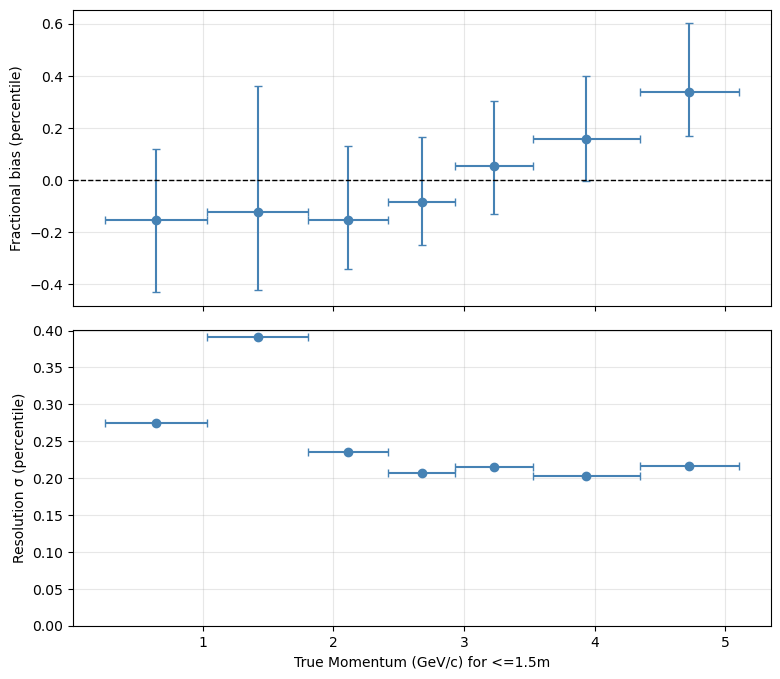

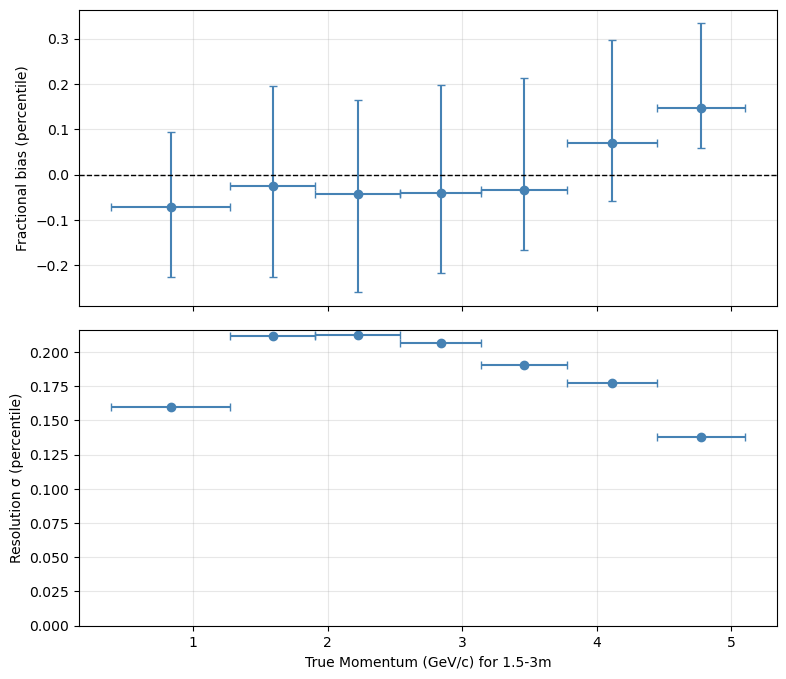

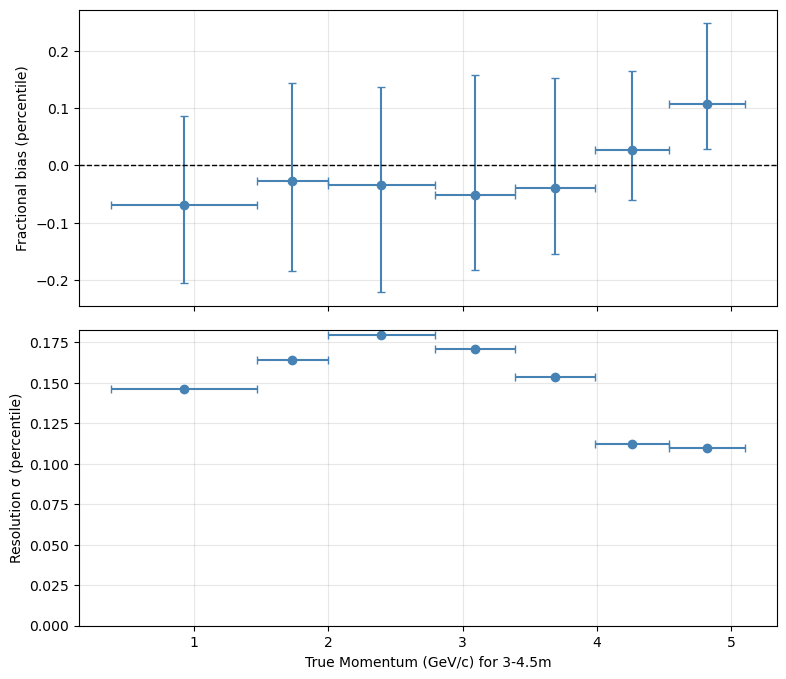

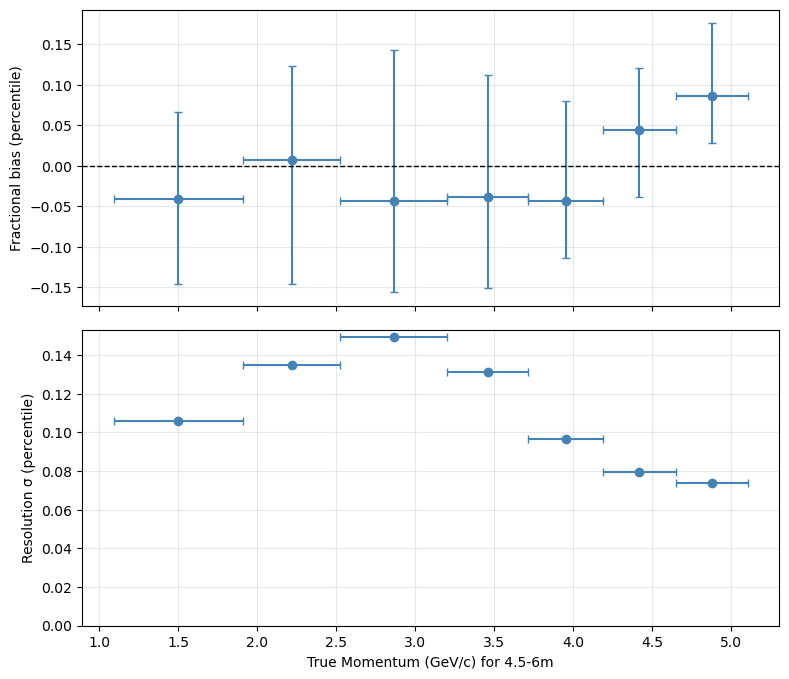

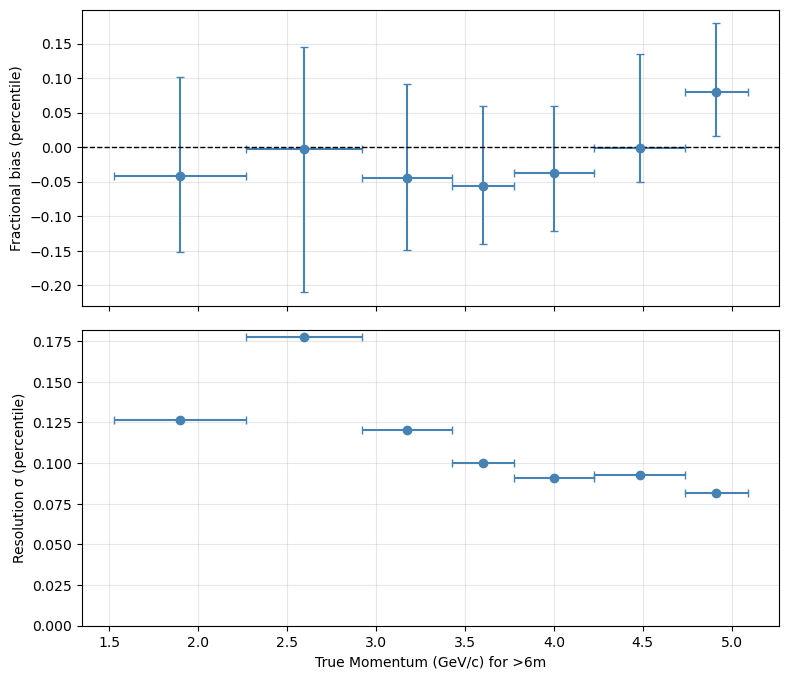

In [14]:
# ── Bias & resolution vs True  for length based plots────────────────────────────────────────────────
resid   = trues / preds - 1.0            #  (1/p_pred - 1/p_true)/(1/p_true)
ok      = np.isfinite(resid) & (trues > 0) & (preds > 0)
trues_f = trues[ok]
resid_f = resid[ok]
N_BINS  = 7
#section trues on length
trues_f_arr = [] #array for all
trues_f0 = [] # len <1.5m
trues_f1 = [] # 1.5-3m
trues_f2 = [] # 3- 4.5 m
trues_f3 = [] # 4.5 - 6m
trues_f4 = [] # >=6m
#section resid on length
resid_f_arr = [] #array for all
resid_f0 = [] # len <=1.5m
resid_f1 = [] # 1.5-3m
resid_f2 = [] # 3- 4.5 m
resid_f3 = [] # 4.5 - 6m
resid_f4 = [] # >=6m
#do sectioning
for i in range (0, len(trues_f)):
    if (dist_f[i] <150):
        trues_f0.append(trues_f[i])
        resid_f0.append(resid_f[i])
    if (dist_f[i] >=150):
        if (dist_f[i] < 300):
            trues_f1.append(trues_f[i])
            resid_f1.append(resid_f[i])
    if (dist_f[i] >=300):
        if (dist_f[i] < 450):
            trues_f2.append(trues_f[i])
            resid_f2.append(resid_f[i])
    if (dist_f[i] >=450):
         if (dist_f[i] < 600):
            trues_f3.append(trues_f[i])
            resid_f3.append(resid_f[i])
    if (dist_f[i] >=600):
        trues_f4.append(trues_f[i])
        resid_f4.append(resid_f[i])
#put into one big array
trues_f_arr.append(trues_f0)
trues_f_arr.append(trues_f1)
trues_f_arr.append(trues_f2)
trues_f_arr.append(trues_f3)
trues_f_arr.append(trues_f4)
# FIX: resid_f0..4 were filled but never collected here
resid_f_arr.append(resid_f0)
resid_f_arr.append(resid_f1)
resid_f_arr.append(resid_f2)
resid_f_arr.append(resid_f3)
resid_f_arr.append(resid_f4)
# FIX: range(0,4) skipped trues_f4 (>= 6 m)

length_4_plot = ['<=1.5m', '1.5-3m', '3-4.5m', '4.5-6m', '>6m']

for n in range (0,5):
    # FIX: list -> np.array so boolean masking works; take matching residuals
    tf = np.array(trues_f_arr[n])
    rf = np.array(resid_f_arr[n]) # FIX: missed it previously

    edges   = np.percentile(tf, np.linspace(0, 100, 8)) # 8 comes from N Bins +1
    centers = (edges[:-1] + edges[1:]) / 2 / 1000
    xwidth  = (edges[1:] - edges[:-1]) / 2 / 1000
    mu_vals, sig_vals, lo_err, hi_err = [], [], [], []
    bin_r = []

    for a, b in zip(edges[:-1], edges[1:]):
        r = rf[(tf >= a) & (tf < b)]
        bin_r.append((r, a, b))
        if len(r) < 10:
            for L in (mu_vals, sig_vals, lo_err, hi_err): L.append(np.nan)
            continue
        if METHOD == 'gaussian':
            mu, sg = norm.fit(r)
            mu_vals.append(mu); sig_vals.append(sg)
            lo_err.append(sg);  hi_err.append(sg)        # symmetric
        else:  # percentile
            p16, p50, p84 = np.percentile(r, [16, 50, 84])
            mu_vals.append(p50); sig_vals.append((p84 - p16) / 2)
            lo_err.append(p50 - p16); hi_err.append(p84 - p50)  # asymmetric
    mu_vals = np.array(mu_vals); sig_vals = np.array(sig_vals)
    yerr    = np.array([lo_err, hi_err])
    fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)
    fig.subplots_adjust(hspace=0.08)
    
    axes[0].errorbar(centers, mu_vals, xerr=xwidth, yerr=yerr, fmt='o',
                 color='steelblue', capsize=3)
    axes[0].axhline(0, color='black', ls='--', lw=1)
    axes[0].set_ylabel(f'Fractional bias ({METHOD})')
    axes[0].grid(True, alpha=0.3)
    axes[1].errorbar(centers, sig_vals, xerr=xwidth, fmt='o',
                 color='steelblue', capsize=3)
    axes[1].set_ylabel(f'Resolution σ ({METHOD})')
    axes[1].set_xlabel(f'True Momentum (GeV/c) for {length_4_plot[n]}')
    axes[1].set_ylim(bottom=0)
    axes[1].grid(True, alpha=0.3)
    plt.show()